In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

In [62]:
from sympy.abc import x,t

In [63]:
f = sp.Piecewise((1 + t, (t <= 0) & (t >= -1)), (1 - t, (t >= 0) & (t <= 1)))
f

Piecewise((t + 1, (t >= -1) & (t <= 0)), (1 - t, (t >= 0) & (t <= 1)))

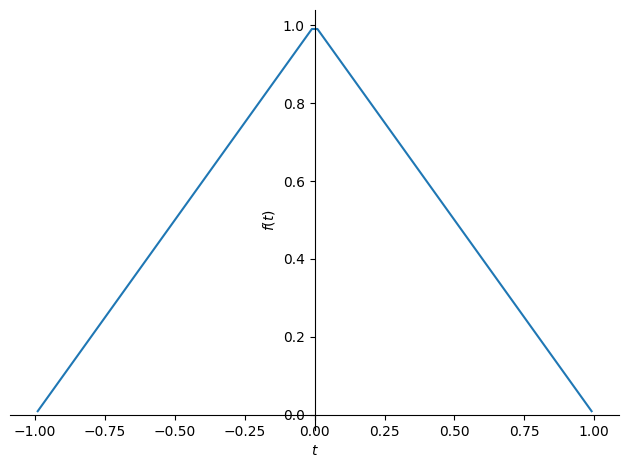

In [64]:
sp.plot(f)

In [65]:
g=f.subs(t,1.5*t+1)

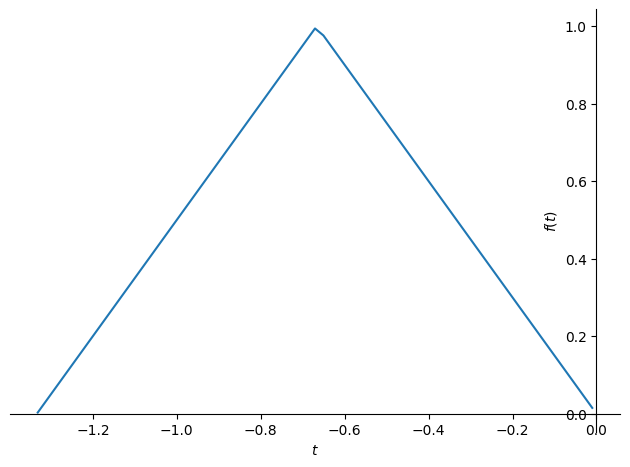

In [66]:
sp.plot(g)

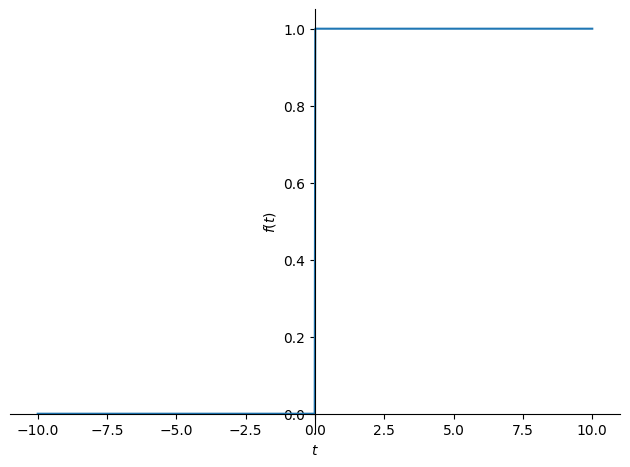

In [67]:
sp.plot(sp.Heaviside(t))

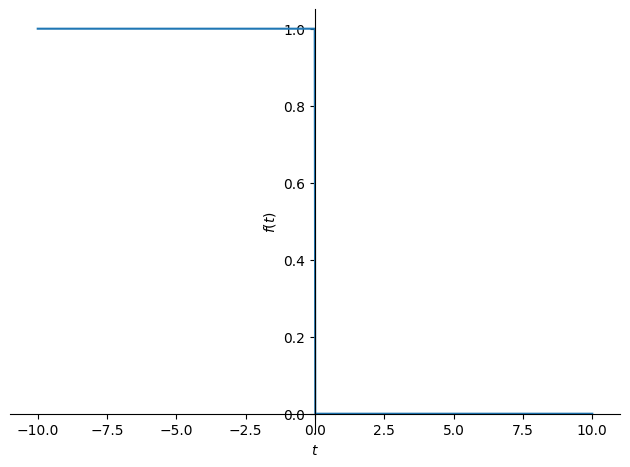

In [68]:
sp.plot(sp.Heaviside(-t))

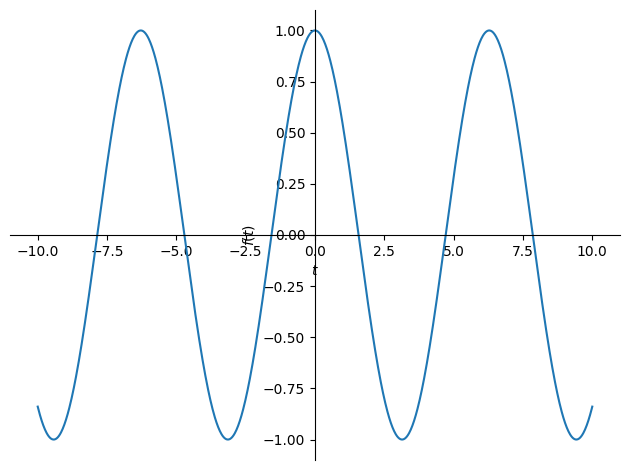

In [69]:
sp.plot(sp.cos(t))

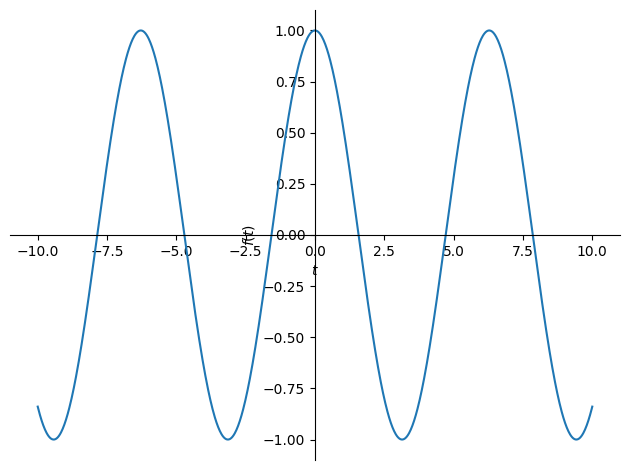

In [70]:
sp.plot(sp.cos(-t))

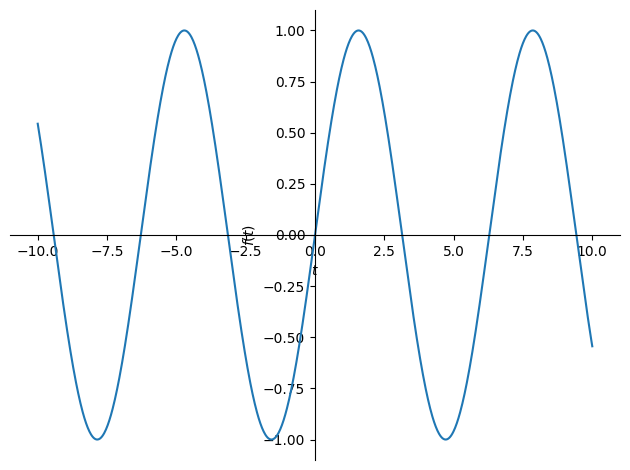

In [71]:
sp.plot(sp.sin(t))

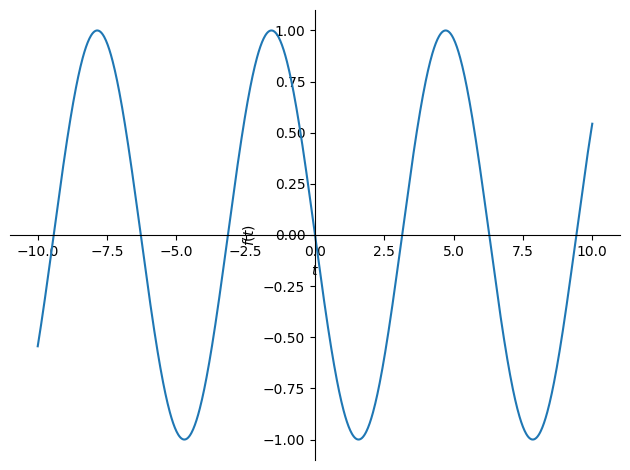

In [72]:
sp.plot(sp.sin(-t))

In [73]:
f=sp.Piecewise((0,(t<0)),(1,(t>=0) &(t<=3)),(4-t,(t>=3)&(t<=4)))
f

Piecewise((0, t < 0), (1, t <= 3), (4 - t, (t >= 3) & (t <= 4)))

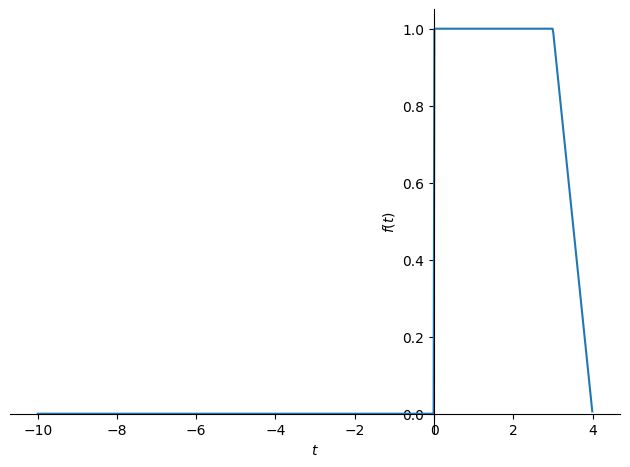

In [74]:
sp.plot(f)

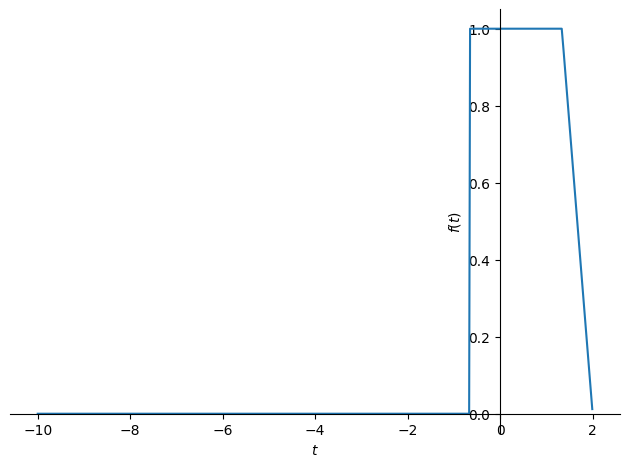

In [75]:
g=f.subs(t,(1.5*t+1))
sp.plot(g)

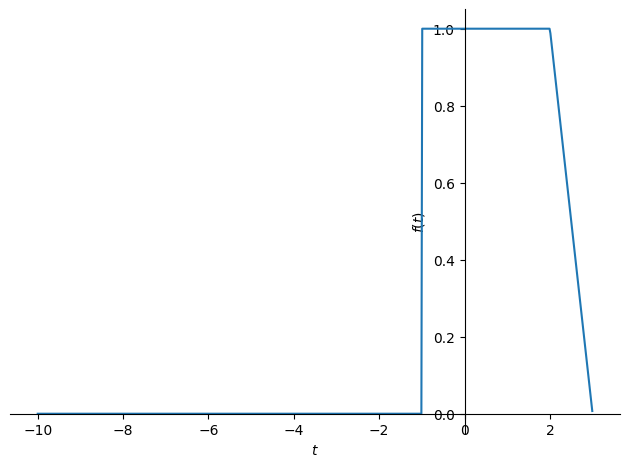

In [76]:
sp.plot(f.subs(t,t+1))

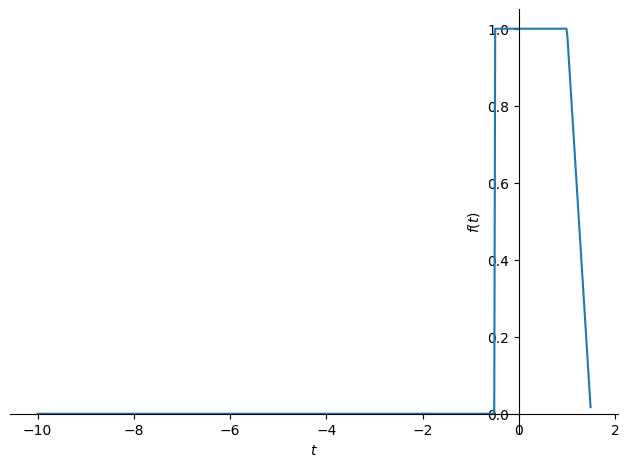

In [77]:
sp.plot(f.subs(t,2*t+1))

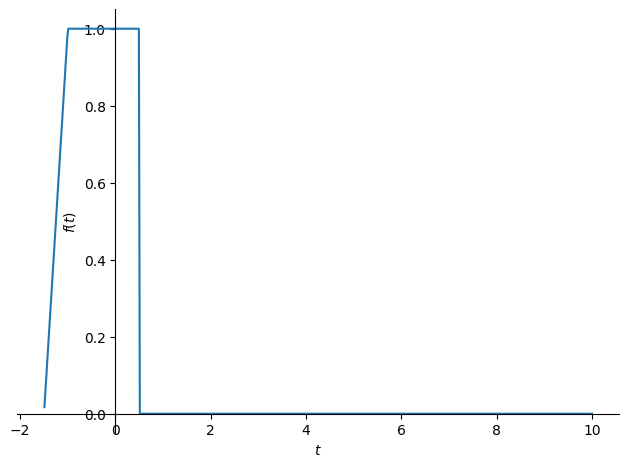

In [78]:
sp.plot(f.subs(t,-2*t+1))

In [79]:
sp.expand((sp.cos(x)**2))

cos(x)**2

In [171]:
n=np.arange(9)
t=np.linspace(0,8,1000)


In [172]:
n

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [173]:
y=np.cos(3*np.pi*n/4)

In [174]:
y

array([ 1.00000000e+00, -7.07106781e-01, -1.83697020e-16,  7.07106781e-01,
       -1.00000000e+00,  7.07106781e-01,  5.51091060e-16, -7.07106781e-01,
        1.00000000e+00])

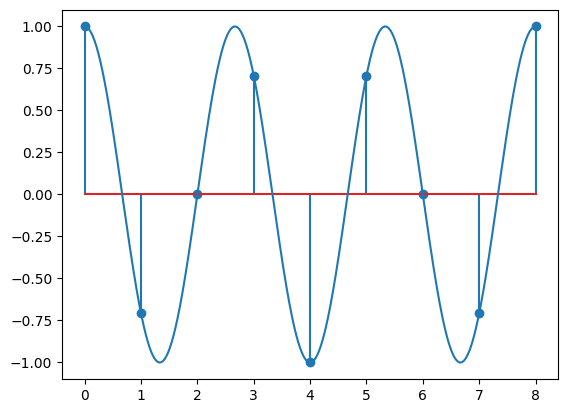

In [175]:
plt.stem(n,y)
plt.plot(t,np.cos(3*np.pi*t/4))

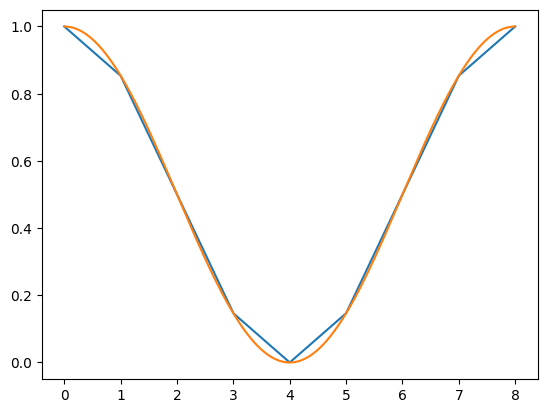

In [176]:
plt.plot(t,poly(t))
plt.plot(t,(np.cos(np.pi*t/8))**2)

In [177]:
y=np.cos((np.pi*n/8))**2
y

array([1.00000000e+00, 8.53553391e-01, 5.00000000e-01, 1.46446609e-01,
       3.74939946e-33, 1.46446609e-01, 5.00000000e-01, 8.53553391e-01,
       1.00000000e+00])

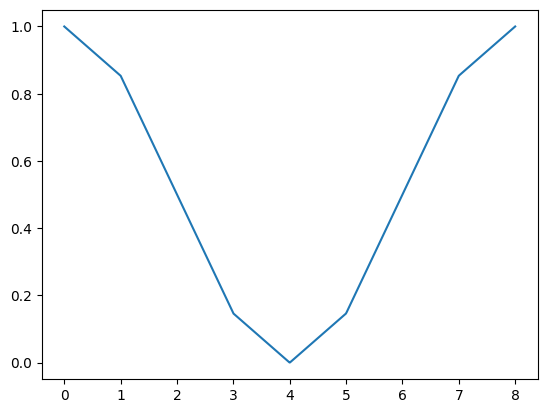

In [182]:
poly=interpolate.(n,y)
poly(t)
plt.plot(t,poly(t))

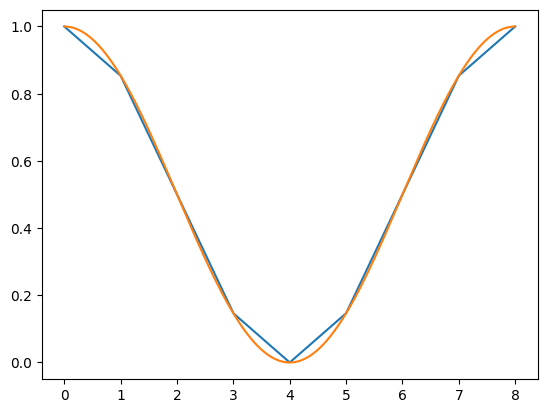

In [191]:
poly=interpolate.interp1d(n,y,kind="linear")
plt.plot(t,poly(t))
plt.plot(t,(np.cos(np.pi*t/8))**2)

In [166]:
n=np.linspace(0,8,1000)

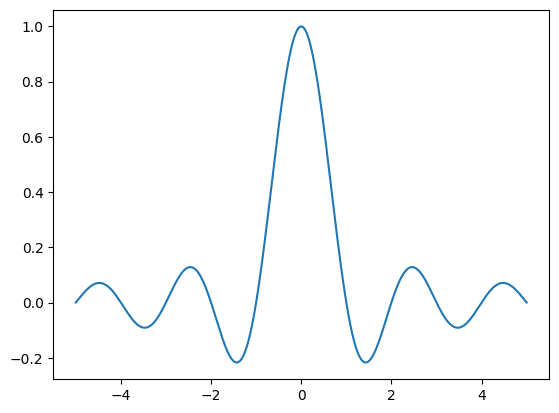

In [198]:
t=np.linspace(-5,5,1000)
y=np.sin(np.pi*t)/(np.pi*t)
plt.plot(t,y)


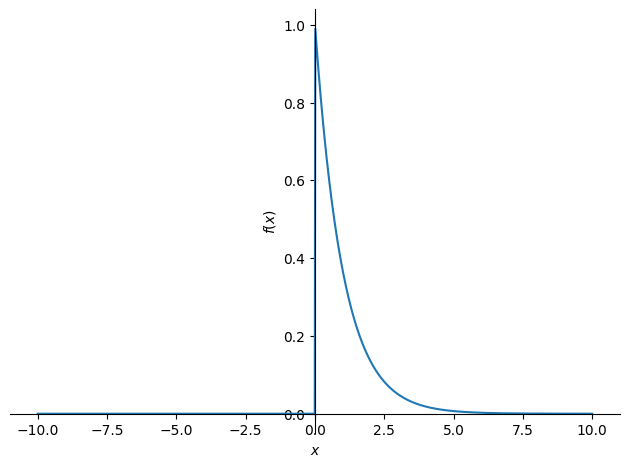

In [217]:

sp.plot(sp.exp(-x)*sp.Heaviside(x))

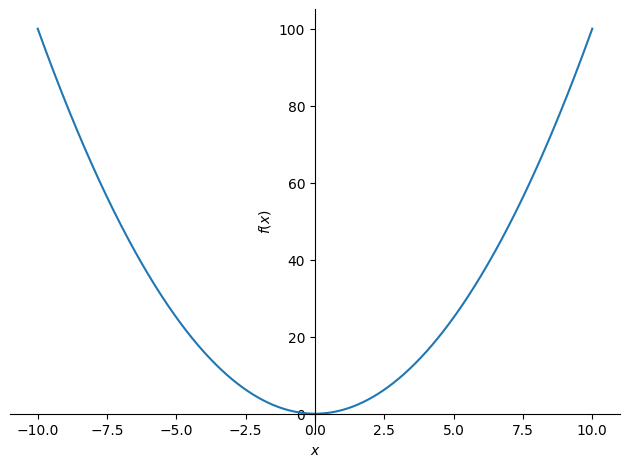

In [208]:
sp.plot(x**2)

In [218]:
from sympy.abc import t

In [224]:
f=(sp.exp(-t)*sp.Heaviside(t)-sp.exp(t)*sp.Heaviside(-t))/2

In [220]:
f

-exp(t)*Heaviside(-t)/2 + exp(-t)*Heaviside(t)/2

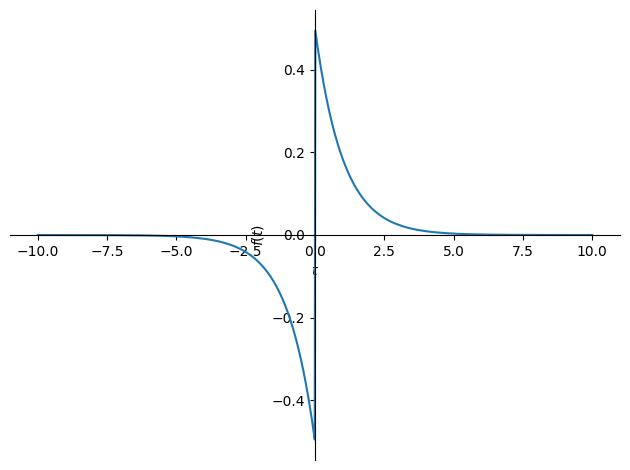

In [221]:
sp.plot(f)

In [227]:
g=(sp.exp(-t)*sp.Heaviside(t)+sp.exp(t)*sp.Heaviside(-t))/2

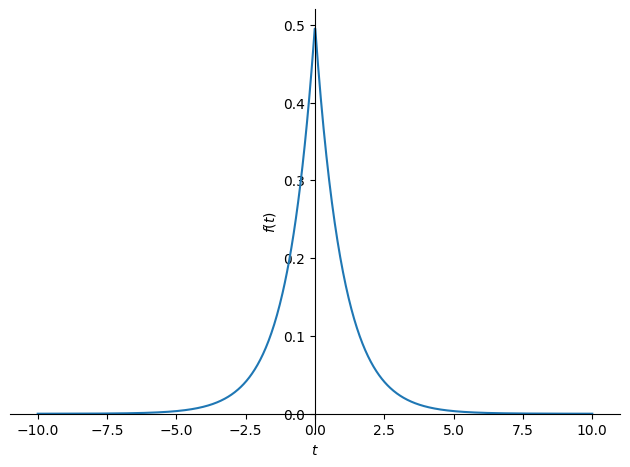

In [229]:
sp.plot(g)

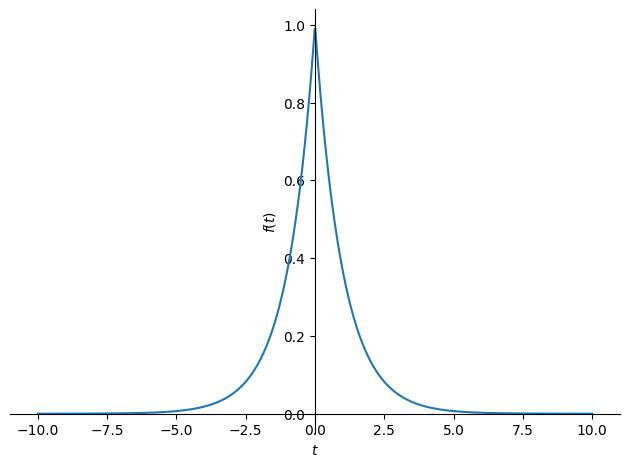

In [231]:
sp.plot((f+g))

In [232]:
h=sp.exp(-t)*sp.Heaviside(t)

In [233]:
h

exp(-t)*Heaviside(t)

In [251]:
sp.integrate(f**2,(t,-sp.oo,sp.oo))

1/4

In [253]:
sp.integrate(g**2,(t,-sp.oo,sp.oo))

1/4

In [254]:
sp.integrate(h**2,(t,-sp.oo,sp.oo))

1/2

Synchronization occurs at t ≈ 0.4166 s


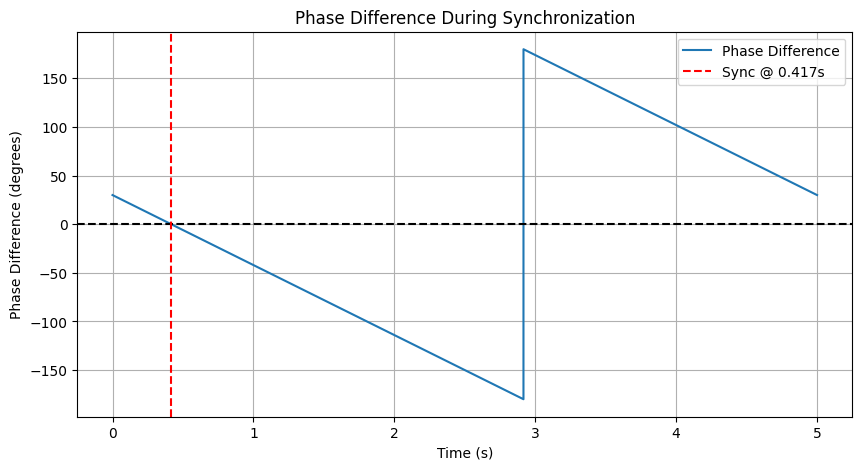

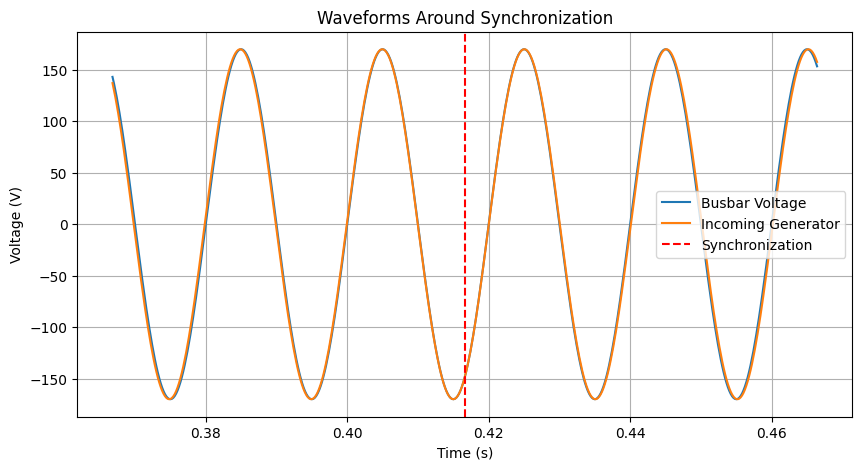

In [3]:
 import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -------------------------
# System Parameters
# -------------------------
V = 170                 # Peak voltage (120 Vrms ≈ 170 Vpeak)
f_bus = 50              # Busbar frequency (Hz)
f_gen = 49.8            # Incoming alternator frequency (Hz)

phi0 = np.deg2rad(30)   # Initial phase difference

# Simulation time
t_end = 5
Fs = 5000

t = np.linspace(0, t_end, int(Fs*t_end))

# Signals
v_bus = V*np.sin(2*np.pi*f_bus*t)
v_gen = V*np.sin(2*np.pi*f_gen*t + phi0)

# Instantaneous phase difference
delta = phi0 + 2*np.pi*(f_gen-f_bus)*t

# Wrap to [-pi, pi]
delta_wrapped = np.arctan2(np.sin(delta), np.cos(delta))

# Find synchronization instant
idx_sync = np.argmin(np.abs(delta_wrapped))
t_sync = t[idx_sync]

print(f"Synchronization occurs at t ≈ {t_sync:.4f} s")

# -------------------------
# Plot 1: Phase Difference
# -------------------------
plt.figure(figsize=(10,5))

plt.plot(t, np.rad2deg(delta_wrapped),
         label='Phase Difference')

plt.axhline(0,color='k',linestyle='--')

plt.axvline(t_sync,
            color='r',
            linestyle='--',
            label=f'Sync @ {t_sync:.3f}s')

plt.xlabel("Time (s)")
plt.ylabel("Phase Difference (degrees)")
plt.title("Phase Difference During Synchronization")
plt.grid(True)
plt.legend()

plt.show()

# -------------------------
# Plot 2: Signals near sync
# -------------------------
window = 0.05

mask = (t > t_sync-window) & (t < t_sync+window)

plt.figure(figsize=(10,5))

plt.plot(t[mask],v_bus[mask],
         label='Busbar Voltage')

plt.plot(t[mask],v_gen[mask],
         label='Incoming Generator')

plt.axvline(t_sync,
            color='r',
            linestyle='--',
            label='Synchronization')

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Waveforms Around Synchronization")
plt.grid(True)
plt.legend()

plt.show()